In [1]:
from dd_ds import *f

Implied initial S0 from Δ0=0.10: 97.054
Implied initial S0 from Δ0=0.20: 98.014
Implied initial S0 from Δ0=0.40: 99.312
Implied initial S0 from Δ0=0.50: 99.876
Implied initial S0 from Δ0=0.60: 100.443
Implied initial S0 from Δ0=0.80: 101.773
Implied initial S0 from Δ0=0.90: 102.779
Combined Delta Differences DataFrame (Interpolated):
             Δ₀=0.1    Δ₀=0.2    Δ₀=0.4   Δ₀=0.5    Δ₀=0.6    Δ₀=0.8    Δ₀=0.9
-6.166761 -0.061641 -0.102094 -0.144935 -0.15027 -0.145389 -0.103162 -0.062629
-6.104784 -0.061641 -0.102094 -0.144935 -0.15027 -0.145389 -0.103162 -0.062629
-6.042806 -0.061641 -0.102094 -0.144935 -0.15027 -0.145389 -0.103162 -0.062629
-5.980829 -0.061641 -0.102094 -0.144935 -0.15027 -0.145389 -0.103162 -0.062629
-5.918851 -0.061641 -0.102094 -0.144935 -0.15027 -0.145389 -0.103162 -0.062629


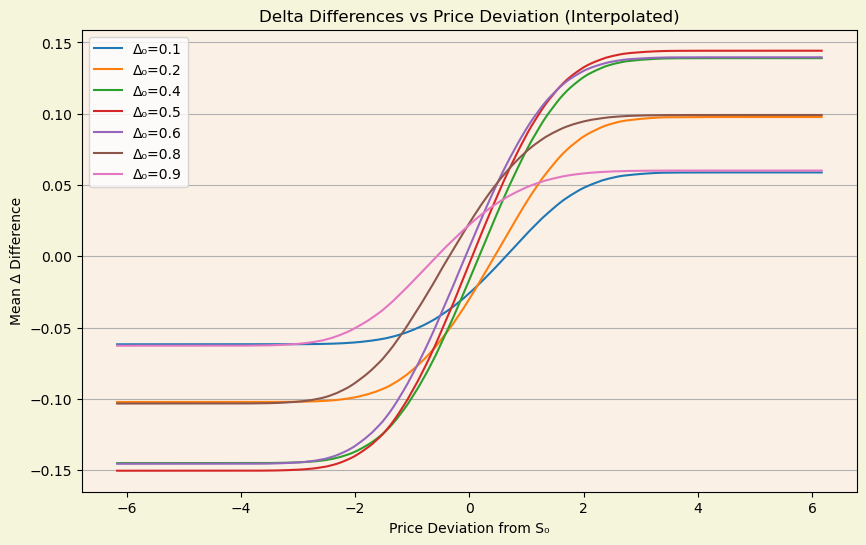

In [8]:
if __name__ == "__main__":
    # Create the simulator with a fixed number of Monte Carlo paths.
    simulator = DeltaSimulator(
        K=100,
        r=0.05,
        sigma=1/100.0 * np.sqrt(252),
        T=5/252,
        delta_t=1/252,
        mu=0.07,
        N_MC=100_000
    )

    # Define a list of initial deltas for which to simulate.
    initial_deltas = [0.1, 0.2, 0.4, 0.5, 0.6, 0.8, 0.9]

    # Dictionary to store the simulation results (pandas Series).
    sim_results = {}

    for delta in initial_deltas:
        sim_series = simulator.simulate(delta)
        sim_results[f"Δ₀={delta}"] = sim_series

    # Combine the results onto a common grid.
    # First, determine the global minimum and maximum of the price deviations.
    all_indices = np.concatenate([s.index.values for s in sim_results.values()])
    global_min = all_indices.min()
    global_max = all_indices.max()

    # Define a common grid (for example, 200 evenly spaced points between global_min and global_max).
    common_grid = np.linspace(global_min, global_max, 200)

    # Interpolate each simulation series onto the common grid.
    interpolated = {}
    for key, series in sim_results.items():
        # Ensure the series is sorted by the index.
        series = series.sort_index()
        # Use np.interp to interpolate the values on the common grid.
        new_values = np.interp(common_grid, series.index.values, series.values)
        interpolated[key] = pd.Series(new_values, index=common_grid, name=key)

    # Combine the interpolated series into a single DataFrame.
    df = pd.DataFrame(interpolated)
    
    print("Combined Delta Differences DataFrame (Interpolated):")
    print(df.head())
    # Set up cavas
    # Plotting
    fig, ax = plt.subplots(figsize=(10, 6))
    fig.patch.set_facecolor('#F5F5DC')  # Light beige background
    ax.set_facecolor('#FAF0E6')  # Lighter beige for the plot area
    ax.grid(True, axis='y')
    ax.grid(False, axis='x')  # Opti
    # Optionally, plot the results.
    df.plot(ax=ax, title="Delta Differences vs Price Deviation (Interpolated)")
    plt.xlabel("Price Deviation from S₀")
    plt.ylabel("Mean Δ Difference")
    plt.grid(True, axis='y')

    plt.show()
